# IEEE-CIS Fraud Detection - Team 2 Member 3 LightGBM Baseline

This notebook is a Colab-first baseline for **Team 2 / Member 3**.

- Load the merged Team 1 parquet outputs
- Prepare categorical and numeric features for tree-based ML
- Train a **LightGBM** fraud baseline with early stopping
- Evaluate with ROC-AUC on a holdout split
- Save the trained model, feature importance, metrics, and test predictions to Google Drive


## 1. Runtime setup

Before running the notebook:

1. In Colab, set runtime to **GPU**.
2. Make sure the Team 1 merged parquet outputs already exist in Google Drive.
3. Run cells from top to bottom.


In [1]:
from pathlib import Path

RANDOM_SEED = 42
TARGET_COLUMN = "isFraud"
ID_COLUMN = "TransactionID"
VALID_SIZE = 0.2
SMOKE_TEST = False
SMOKE_ROWS = 100_000

# Edit only this section when adapting the notebook.
DATA_ROOT = Path("/content/drive/MyDrive/ieee_cis_fraud")
MERGED_DIR = DATA_ROOT / "merged"
OUTPUT_DIR = DATA_ROOT / "member3_baseline"
TRAIN_PATH = MERGED_DIR / "train_member1_member2_merged.parquet"
TEST_PATH = MERGED_DIR / "test_member1_member2_merged.parquet"
SAMPLE_SUBMISSION_PATH = None

MODEL_PATH = OUTPUT_DIR / "member3_lgbm_baseline.txt"
METRICS_PATH = OUTPUT_DIR / "member3_lgbm_metrics.json"
FEATURE_IMPORTANCE_PATH = OUTPUT_DIR / "member3_lgbm_feature_importance.csv"
VALID_PREDICTIONS_PATH = OUTPUT_DIR / "member3_lgbm_validation_predictions.parquet"
TEST_PREDICTIONS_PATH = OUTPUT_DIR / "member3_lgbm_test_predictions.parquet"
SUBMISSION_PATH = OUTPUT_DIR / "member3_lgbm_submission.csv"

TRAIN_PATH, TEST_PATH, OUTPUT_DIR

(PosixPath('/content/drive/MyDrive/ieee_cis_fraud/merged/train_member1_member2_merged.parquet'),
 PosixPath('/content/drive/MyDrive/ieee_cis_fraud/merged/test_member1_member2_merged.parquet'),
 PosixPath('/content/drive/MyDrive/ieee_cis_fraud/member3_baseline'))

In [2]:
!pip -q install lightgbm scikit-learn pyarrow pandas matplotlib seaborn

In [3]:
from google.colab import drive

drive.mount('/content/drive')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"TEST_PATH: {TEST_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Mounted at /content/drive
TRAIN_PATH: /content/drive/MyDrive/ieee_cis_fraud/merged/train_member1_member2_merged.parquet
TEST_PATH: /content/drive/MyDrive/ieee_cis_fraud/merged/test_member1_member2_merged.parquet
OUTPUT_DIR: /content/drive/MyDrive/ieee_cis_fraud/member3_baseline


In [4]:
import gc
import json

import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lightgbm.basic import LightGBMError
from sklearn.metrics import roc_auc_score


def memory_usage_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 1024 ** 2


def align_categorical_columns(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    train_df = train_df.copy()
    test_df = test_df.copy()

    categorical_columns = []
    for col in train_df.columns:
        if col in {TARGET_COLUMN, ID_COLUMN}:
            continue
        if train_df[col].dtype == 'object' or str(train_df[col].dtype).startswith('string') or str(test_df[col].dtype).startswith('object'):
            combined = pd.concat([
                train_df[col].astype('string').fillna('__MISSING__'),
                test_df[col].astype('string').fillna('__MISSING__')
            ], axis=0)
            categories = pd.Index(sorted(combined.unique()))
            train_df[col] = pd.Categorical(train_df[col].astype('string').fillna('__MISSING__'), categories=categories)
            test_df[col] = pd.Categorical(test_df[col].astype('string').fillna('__MISSING__'), categories=categories)
            categorical_columns.append(col)
    return train_df, test_df, categorical_columns


def train_lightgbm_baseline(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    categorical_columns: list[str],
) -> tuple[lgb.LGBMClassifier, str]:
    base_params = {
        'objective': 'binary',        # Binary classification task (0/1 output)
        'metric': 'auc',              # Evaluate model using ROC-AUC score
        'n_estimators': 4000,         # Max number of boosting rounds (trees)
        'learning_rate': 0.03,        # Step size per tree — low = slower but more precise
        'num_leaves': 127,            # Max leaves per tree — controls model complexity
        'max_depth': -1,              # No depth limit (controlled by num_leaves instead)
        'subsample': 0.8,             # Use 80% of rows per tree — reduces overfitting
        'subsample_freq': 1,          # Apply subsampling every iteration
        'colsample_bytree': 0.8,      # Use 80% of features per tree — reduces overfitting
        'reg_alpha': 0.1,             # L1 regularization — promotes sparsity
        'reg_lambda': 1.0,            # L2 regularization — penalizes large weights
        'min_child_samples': 50,      # Min samples required in a leaf — prevents overfitting
        'random_state': RANDOM_SEED,  # Seed for reproducibility
        'n_jobs': -1,                 # Use all CPU cores for training
        'is_unbalance': True,         # Auto-adjust weights for imbalanced classes
        'verbosity': -1,              # Suppress all training logs
    }
    fit_kwargs = {
        'eval_set': [(X_valid, y_valid)],
        'eval_metric': 'auc',
        'categorical_feature': categorical_columns,
        'callbacks': [
            lgb.early_stopping(200),
            lgb.log_evaluation(100),
        ],
    }

    try:
        print('Trying LightGBM with GPU...')
        model = lgb.LGBMClassifier(**base_params, device_type='gpu')
        model.fit(X_train, y_train, **fit_kwargs)
        return model, 'gpu'
    except (LightGBMError, RuntimeError, ValueError) as exc:
        print(f'GPU training failed, falling back to CPU: {exc}')
        model = lgb.LGBMClassifier(**base_params, device_type='cpu')
        model.fit(X_train, y_train, **fit_kwargs)
        return model, 'cpu'


In [5]:
assert TRAIN_PATH.exists(), f'Missing train parquet: {TRAIN_PATH}'
assert TEST_PATH.exists(), f'Missing test parquet: {TEST_PATH}'

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

if SMOKE_TEST:
    train_df = train_df.sample(n=min(SMOKE_ROWS, len(train_df)), random_state=RANDOM_SEED).reset_index(drop=True)
    test_df = test_df.sample(n=min(SMOKE_ROWS, len(test_df)), random_state=RANDOM_SEED).reset_index(drop=True)

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
print('train memory (MB):', round(memory_usage_mb(train_df), 2))
print('test memory (MB):', round(memory_usage_mb(test_df), 2))

train shape: (590540, 490)
test shape: (506691, 489)
train memory (MB): 1859.64
test memory (MB): 1604.42


In [6]:
assert TARGET_COLUMN in train_df.columns, f'{TARGET_COLUMN} missing from train data.'
assert TARGET_COLUMN not in test_df.columns, f'{TARGET_COLUMN} should not exist in test data.'
assert ID_COLUMN in train_df.columns and ID_COLUMN in test_df.columns, f'{ID_COLUMN} missing from inputs.'

train_shape_full = train_df.shape
test_shape_full = test_df.shape

train_ids = train_df[ID_COLUMN].copy()
test_ids = test_df[ID_COLUMN].copy()
y = train_df[TARGET_COLUMN].copy()

X = train_df.drop(columns=[TARGET_COLUMN])
X_test = test_df.copy()

X, X_test, categorical_columns = align_categorical_columns(X, X_test)

del train_df, test_df
gc.collect()

feature_columns = X.columns.tolist()
print('Number of features:', len(feature_columns))
print('Categorical features:', len(categorical_columns))
print('Sample categorical features:', categorical_columns[:10])

Number of features: 489
Categorical features: 31
Sample categorical features: ['card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6']


In [7]:
assert 'TransactionDT' in X.columns, 'TransactionDT is required for a chronological validation split.'

sorted_order = X['TransactionDT'].sort_values(kind='mergesort').index
X = X.loc[sorted_order].reset_index(drop=True)
y = y.loc[sorted_order].reset_index(drop=True)
train_ids = train_ids.loc[sorted_order].reset_index(drop=True)

split_idx = int(len(X) * (1 - VALID_SIZE))
X_train = X.iloc[:split_idx].copy()
X_valid = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_valid = y.iloc[split_idx:].copy()
train_id_split = train_ids.iloc[:split_idx].copy()
valid_id_split = train_ids.iloc[split_idx:].copy()

del X, y, train_ids
gc.collect()

print('Using chronological validation split based on TransactionDT.')
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('Train TransactionDT range:', (X_train['TransactionDT'].min(), X_train['TransactionDT'].max()))
print('Valid TransactionDT range:', (X_valid['TransactionDT'].min(), X_valid['TransactionDT'].max()))
print('Fraud rate train:', round(y_train.mean(), 6))
print('Fraud rate valid:', round(y_valid.mean(), 6))

Using chronological validation split based on TransactionDT.
X_train: (472432, 489)
X_valid: (118108, 489)
Train TransactionDT range: (86400, 12192842)
Valid TransactionDT range: (12192900, 15811131)
Fraud rate train: 0.035135
Fraud rate valid: 0.034409


In [8]:
model, device_used = train_lightgbm_baseline(
    X_train,
    y_train,
    X_valid,
    y_valid,
    categorical_columns,
)

print('Training completed.')
print('Device used:', device_used)
print('Best iteration:', model.best_iteration_)

Trying LightGBM with GPU...
Training until validation scores don't improve for 200 rounds
[100]	valid_0's auc: 0.906053
[200]	valid_0's auc: 0.912158
[300]	valid_0's auc: 0.912588
[400]	valid_0's auc: 0.912639
[500]	valid_0's auc: 0.912529
[600]	valid_0's auc: 0.913501
[700]	valid_0's auc: 0.91327
[800]	valid_0's auc: 0.913702
[900]	valid_0's auc: 0.914243
[1000]	valid_0's auc: 0.914324
[1100]	valid_0's auc: 0.914435
[1200]	valid_0's auc: 0.914648
[1300]	valid_0's auc: 0.915029
[1400]	valid_0's auc: 0.915492
[1500]	valid_0's auc: 0.915674
[1600]	valid_0's auc: 0.91572
[1700]	valid_0's auc: 0.91595
[1800]	valid_0's auc: 0.915978
[1900]	valid_0's auc: 0.916377
[2000]	valid_0's auc: 0.916323
[2100]	valid_0's auc: 0.916511
[2200]	valid_0's auc: 0.916647
[2300]	valid_0's auc: 0.916752
[2400]	valid_0's auc: 0.916871
[2500]	valid_0's auc: 0.917057
[2600]	valid_0's auc: 0.917366
[2700]	valid_0's auc: 0.917722
[2800]	valid_0's auc: 0.917667
Early stopping, best iteration is:
[2673]	valid_0's au

In [9]:
valid_scores = model.predict_proba(X_valid, num_iteration=model.best_iteration_)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_scores)

print('Validation ROC-AUC:', round(valid_auc, 6))

Validation ROC-AUC: 0.917777


,feature,importance_gain,importance_split
0,member2_v_pca_01,1.228164e+06,2457
1,card1,6.262637e+05,20159
2,P_emaildomain,6.016588e+05,8050
3,C14,5.611572e+05,2333
4,card2,4.921560e+05,14611
5,DeviceInfo,4.318694e+05,6006
6,V258,4.260245e+05,135
7,id_31,4.246047e+05,6624
8,addr1,4.191903e+05,14135
9,TransactionAmt,3.497705e+05,10589


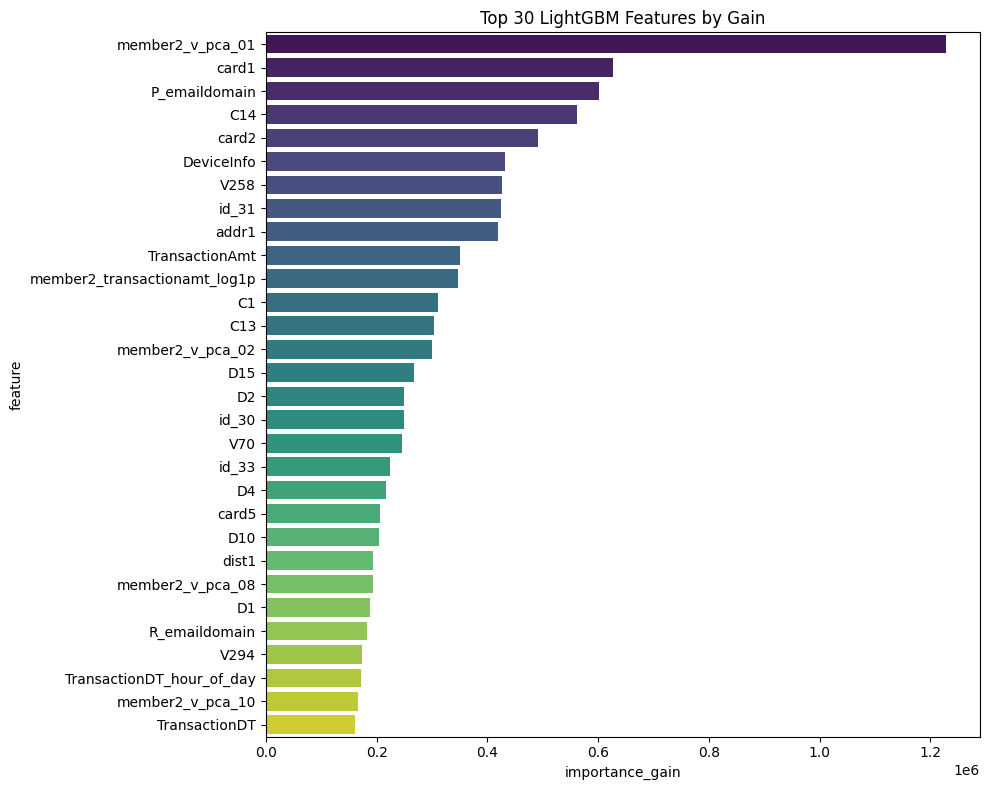

In [10]:
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance_gain': model.booster_.feature_importance(importance_type='gain'),
    'importance_split': model.booster_.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

top_importance = importance_df.head(30)
display(top_importance)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_importance, x='importance_gain', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 30 LightGBM Features by Gain')
plt.tight_layout()
plt.show()

In [11]:
test_scores = model.predict_proba(X_test, num_iteration=model.best_iteration_)[:, 1]

valid_predictions = pd.DataFrame({
    ID_COLUMN: valid_id_split.values,
    TARGET_COLUMN: y_valid.values,
    'prediction': valid_scores,
})

test_predictions = pd.DataFrame({
    ID_COLUMN: test_ids.values,
    'prediction': test_scores,
})

display(valid_predictions.head())
display(test_predictions.head())

,TransactionID,isFraud,prediction
0,3459432,1,0.196577
1,3459433,0,0.000002
2,3459434,0,0.035633
3,3459435,0,0.057544
4,3459436,0,0.000012


,TransactionID,prediction
0,3663549,0.000402
1,3663550,0.000262
2,3663551,0.000278
3,3663552,0.001033
4,3663553,0.001701


In [12]:
model.booster_.save_model(str(MODEL_PATH))
importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
valid_predictions.to_parquet(VALID_PREDICTIONS_PATH, index=False)
test_predictions.to_parquet(TEST_PREDICTIONS_PATH, index=False)

metrics = {
    'model': 'lightgbm',
    'device_used': device_used,
    'validation_auc': float(valid_auc),
    'best_iteration': int(model.best_iteration_),
    'num_features': len(feature_columns),
    'num_categorical_features': len(categorical_columns),
    'train_shape': list(train_shape_full),
    'test_shape': list(test_shape_full),
    'valid_shape': list(X_valid.shape),
}

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

if SAMPLE_SUBMISSION_PATH is not None and Path(SAMPLE_SUBMISSION_PATH).exists():
    submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    submission[TARGET_COLUMN] = test_scores
    submission.to_csv(SUBMISSION_PATH, index=False)
    print('Submission saved to:', SUBMISSION_PATH)

print('Saved outputs:')
print('-', MODEL_PATH)
print('-', METRICS_PATH)
print('-', FEATURE_IMPORTANCE_PATH)
print('-', VALID_PREDICTIONS_PATH)
print('-', TEST_PREDICTIONS_PATH)

Saved outputs:
- /content/drive/MyDrive/ieee_cis_fraud/member3_baseline/member3_lgbm_baseline.txt
- /content/drive/MyDrive/ieee_cis_fraud/member3_baseline/member3_lgbm_metrics.json
- /content/drive/MyDrive/ieee_cis_fraud/member3_baseline/member3_lgbm_feature_importance.csv
- /content/drive/MyDrive/ieee_cis_fraud/member3_baseline/member3_lgbm_validation_predictions.parquet
- /content/drive/MyDrive/ieee_cis_fraud/member3_baseline/member3_lgbm_test_predictions.parquet


## 2. Next steps for Member 3

After this baseline runs successfully, the natural next iterations are:

- compare **Member 1 only**, **Member 2 only**, and **Member 1 + 2 merged** inputs
- add **XGBoost** and **CatBoost** baselines
- tune LightGBM with **Optuna**
- hand off validation predictions and test predictions for ensembling and error analysis
